In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Group A Deadline-05 October 26 Model_C1 - Master.csv")

In [3]:
df.head()

,S.No,Country,City,Company,LINKEDIN LINK,Website,Tech Need / Problem,EMAIL,CONTACT,Google Map,Category,Ratings,Reviews
0,1,India,Lucknow,Ladies First Beauty Salon,NaN,NaN,NaN,NaN,7499858640,https://maps.app.goo.gl/zQKMiLRnw9RziQSh6,Beauty Salon,4.5,399
1,2,India,Lucknow,Priya Beauty Salon,NaN,NaN,NaN,NaN,8881200100,https://maps.app.goo.gl/jm5JRZPhwYTUJqSR9,Beauty Salon,4.8,55
2,3,India,Lucknow,Looks,NaN,NaN,NaN,NaN,9919990738,https://maps.app.goo.gl/3B8ZhGzqW2v8Pb5R7,Beauty Salon,4.8,329
3,4,India,Lucknow,Glow N Glam\r,NaN,NaN,NaN,NaN,9919736852,https://maps.app.goo.gl/aQTVy4qYCbXqdmMK6,Beauty Salon,4.6,221
4,5,USA,New York,NY-2 Food Market,NaN,NaN,NaN,NaN,12125822075,https://maps.app.goo.gl/QNWKnhprAJ5gZAmUA,Grocery Store,4.3,55


In [4]:
df.shape

(297, 13)

In [5]:
df.columns.tolist()

['S.No',
 'Country',
 'City',
 'Company',
 'LINKEDIN LINK',
 'Website',
 'Tech Need / Problem',
 'EMAIL',
 'CONTACT',
 'Google Map',
 'Category',
 'Ratings',
 'Reviews']

In [6]:
df.dtypes

S.No                     int64
Country                 object
City                    object
Company                 object
LINKEDIN LINK          float64
Website                float64
Tech Need / Problem    float64
EMAIL                  float64
CONTACT                  int64
Google Map              object
Category                object
Ratings                float64
Reviews                 object
dtype: object

In [7]:
df.dtypes

S.No                     int64
Country                 object
City                    object
Company                 object
LINKEDIN LINK          float64
Website                float64
Tech Need / Problem    float64
EMAIL                  float64
CONTACT                  int64
Google Map              object
Category                object
Ratings                float64
Reviews                 object
dtype: object

In [8]:
df["Clean_Category"] = (
    df["Category"]
    .astype(str)
    .str.strip()
    .str.title()
)

In [9]:
df["Clean_Category"].value_counts()

Clean_Category
Pharmacy                    93
General Store               42
Cake Shop                   41
Restaurant                  23
Tailor                      20
Beauty Salon                20
Garage                      19
Wine Store                  18
Grocery Store               16
Home Goods Store             2
Clothing Store               2
Building Materials Store     1
Name: count, dtype: int64

In [10]:
df["Clean_Category"].unique()

array(['Beauty Salon', 'Grocery Store', 'General Store', 'Pharmacy',
       'Garage', 'Cake Shop', 'Tailor', 'Home Goods Store', 'Wine Store',
       'Restaurant', 'Clothing Store', 'Building Materials Store'],
      dtype=object)

In [11]:
df["Business_Type"] = np.where(
    df["Country"].str.strip().str.lower() == "india",
    "Indian",
    "Foreign"
)

In [12]:
df["Business_Type"].value_counts()

Business_Type
Indian     207
Foreign     90
Name: count, dtype: int64

In [13]:
df.groupby("Business_Type")["Clean_Category"].unique()

Business_Type
Foreign    [Grocery Store, General Store, Pharmacy, Garag...
Indian     [Beauty Salon, Pharmacy, General Store, Cake S...
Name: Clean_Category, dtype: object

In [14]:
pd.crosstab(
    df["Clean_Category"],
    df["Business_Type"]
)

Business_Type,Foreign,Indian
Clean_Category,,
Beauty Salon,1,19
Building Materials Store,1,0
Cake Shop,2,39
Clothing Store,2,0
Garage,19,0
General Store,3,39
Grocery Store,16,0
Home Goods Store,2,0
Pharmacy,6,87


In [15]:
df["Clean_Category"].value_counts()

Clean_Category
Pharmacy                    93
General Store               42
Cake Shop                   41
Restaurant                  23
Tailor                      20
Beauty Salon                20
Garage                      19
Wine Store                  18
Grocery Store               16
Home Goods Store             2
Clothing Store               2
Building Materials Store     1
Name: count, dtype: int64

In [16]:
df["Reviews"] = (
    df["Reviews"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [17]:
df[["Ratings", "Reviews"]].isnull().sum()

Ratings    0
Reviews    0
dtype: int64

In [18]:
df[["Ratings", "Reviews"]].isna().sum()

Ratings    0
Reviews    0
dtype: int64

In [19]:
df[df["Reviews"] == 2175][["Company", "Ratings", "Reviews"]]

,Company,Ratings,Reviews
203,JJ Bakers,4.0,2175


In [20]:
df["Reviews"].dtype

dtype('int64')

In [22]:
df["Rating_Score"] = df["Ratings"] / 5
df[["Ratings", "Rating_Score"]].head(10)

,Ratings,Rating_Score
0,4.5,0.90
1,4.8,0.96
2,4.8,0.96
3,4.6,0.92
4,4.3,0.86
5,4.2,0.84
6,5.0,1.00
7,4.5,0.90
8,4.5,0.90
9,3.5,0.70


In [24]:
df["Log_Reviews"] = np.log1p(df["Reviews"])
df[["Reviews", "Log_Reviews"]].head(10)

,Reviews,Log_Reviews
0,399,5.991465
1,55,4.025352
2,329,5.799093
3,221,5.402677
4,55,4.025352
5,57,4.060443
6,3,1.386294
7,12,2.564949
8,15,2.772589
9,8,2.197225


In [25]:
df["Review_Volume_Score"] = (
    df["Log_Reviews"] - df["Log_Reviews"].min()
) / (
    df["Log_Reviews"].max() - df["Log_Reviews"].min()
)

In [26]:
df[["Reviews", "Review_Volume_Score"]].head(10)

,Reviews,Review_Volume_Score
0,399,0.617785
1,55,0.415057
2,329,0.597949
3,221,0.557074
4,55,0.415057
5,57,0.418675
6,3,0.142942
7,12,0.264474
8,15,0.285884
9,8,0.226558


In [27]:
df[[
    "Ratings",
    "Reviews",
    "Rating_Score",
    "Log_Reviews",
    "Review_Volume_Score"
]].head(10)

,Ratings,Reviews,Rating_Score,Log_Reviews,Review_Volume_Score
0,4.5,399,0.90,5.991465,0.617785
1,4.8,55,0.96,4.025352,0.415057
2,4.8,329,0.96,5.799093,0.597949
3,4.6,221,0.92,5.402677,0.557074
4,4.3,55,0.86,4.025352,0.415057
5,4.2,57,0.84,4.060443,0.418675
6,5.0,3,1.00,1.386294,0.142942
7,4.5,12,0.90,2.564949,0.264474
8,4.5,15,0.90,2.772589,0.285884
9,3.5,8,0.70,2.197225,0.226558


In [28]:
df["Review_Score"] = (
    0.6 * df["Rating_Score"] +
    0.4 * df["Review_Volume_Score"]
)

In [29]:
df[
    [
        "Company",
        "Ratings",
        "Reviews",
        "Rating_Score",
        "Review_Volume_Score",
        "Review_Score"
    ]
].head(15)

,Company,Ratings,Reviews,Rating_Score,Review_Volume_Score,Review_Score
0,Ladies First Beauty Salon,4.5,399,0.90,0.617785,0.787114
1,Priya Beauty Salon,4.8,55,0.96,0.415057,0.742023
2,Looks,4.8,329,0.96,0.597949,0.815180
3,Glow N Glam\r,4.6,221,0.92,0.557074,0.774830
4,NY-2 Food Market,4.3,55,0.86,0.415057,0.682023
5,Noho Food Market,4.2,57,0.84,0.418675,0.671470
6,Parkview Convenience,5.0,3,1.00,0.142942,0.657177
7,NYC convenience (maiden lane),4.5,12,0.90,0.264474,0.645790
8,Sonny's Grocery store,4.5,15,0.90,0.285884,0.654354
9,Chelsea convenience & more,3.5,8,0.70,0.226558,0.510623


In [30]:
df["Review_Score"].describe()

count    297.000000
mean       0.672455
std        0.118486
min        0.000000
25%        0.627692
50%        0.673246
75%        0.747716
max        0.975705
Name: Review_Score, dtype: float64

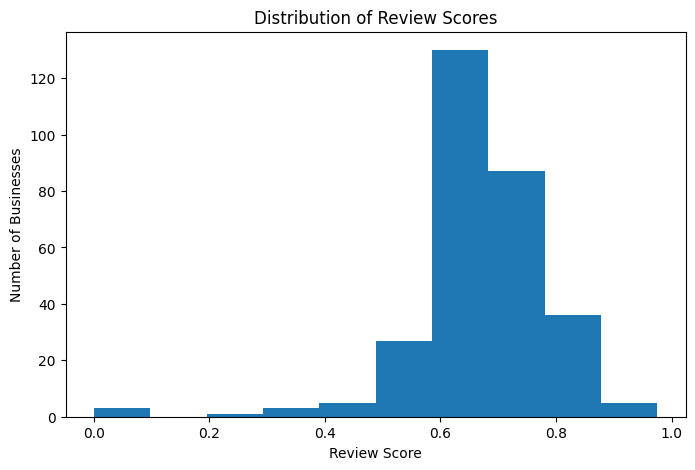

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Review_Score"], bins=10)
plt.xlabel("Review Score")
plt.ylabel("Number of Businesses")
plt.title("Distribution of Review Scores")
plt.show()

In [32]:
df[
    ["Company", "Ratings", "Reviews", "Review_Score"]
].sort_values(
    "Review_Score",
    ascending=False
).head(20)

,Company,Ratings,Reviews,Review_Score
165,Milan A Speciality Restaurant,4.8,16173,0.975705
178,Moti Mahal Restaurant,4.2,16289,0.904000
206,The Cherry Tree Cafe,4.4,8497,0.901161
196,Barkaas Indo-Arabic Restaurant,4.5,5092,0.892046
177,The Mughal's Dastarkhwan,4.2,11214,0.888604
183,The Terrace,4.1,9553,0.869992
180,Royal Sky,4.2,6398,0.865461
181,Hons - All day Dining,4.4,2252,0.846407
133,VR UNISEX SALON,4.9,504,0.844728
15,Mitsuki Japanese Market,4.9,438,0.838951


In [33]:
df[
    ["Company", "Ratings", "Reviews", "Review_Score"]
].sort_values(
    "Review_Score"
).head(20)

,Company,Ratings,Reviews,Review_Score
294,Paras Medical Hall,0.0,0,0.000000
189,New York Clothing Store,0.0,0,0.000000
285,Mahaveer Medical,0.0,0,0.000000
69,Select Garages - 9 Park Ave. Garage,1.2,25,0.278378
90,SFG Garage,1.9,8,0.318623
276,Divya Medico,2.3,3,0.333177
282,Medical Store,2.3,4,0.342380
71,MTP Park,2.8,5,0.409900
47,The 1345 Garage,2.3,37,0.426030
96,S M Bakery,2.8,11,0.438488


In [34]:
df["Review_Score"].describe()

count    297.000000
mean       0.672455
std        0.118486
min        0.000000
25%        0.627692
50%        0.673246
75%        0.747716
max        0.975705
Name: Review_Score, dtype: float64

In [35]:
df[
    ["Company", "Ratings", "Reviews", "Review_Score"]
].sort_values(
    "Review_Score",
    ascending=True
).head(15)

,Company,Ratings,Reviews,Review_Score
294,Paras Medical Hall,0.0,0,0.000000
189,New York Clothing Store,0.0,0,0.000000
285,Mahaveer Medical,0.0,0,0.000000
69,Select Garages - 9 Park Ave. Garage,1.2,25,0.278378
90,SFG Garage,1.9,8,0.318623
276,Divya Medico,2.3,3,0.333177
282,Medical Store,2.3,4,0.342380
71,MTP Park,2.8,5,0.409900
47,The 1345 Garage,2.3,37,0.426030
96,S M Bakery,2.8,11,0.438488


In [36]:
df[
    ["Company", "Ratings", "Reviews", "Review_Score"]
].sort_values(
    "Review_Score",
    ascending=False
).head(15)

,Company,Ratings,Reviews,Review_Score
165,Milan A Speciality Restaurant,4.8,16173,0.975705
178,Moti Mahal Restaurant,4.2,16289,0.904000
206,The Cherry Tree Cafe,4.4,8497,0.901161
196,Barkaas Indo-Arabic Restaurant,4.5,5092,0.892046
177,The Mughal's Dastarkhwan,4.2,11214,0.888604
183,The Terrace,4.1,9553,0.869992
180,Royal Sky,4.2,6398,0.865461
181,Hons - All day Dining,4.4,2252,0.846407
133,VR UNISEX SALON,4.9,504,0.844728
15,Mitsuki Japanese Market,4.9,438,0.838951


In [37]:
df[
    ["Company", "Ratings", "Reviews", "Review_Score"]
].sort_values(
    "Review_Score",
    ascending=True
).head(15)

,Company,Ratings,Reviews,Review_Score
294,Paras Medical Hall,0.0,0,0.000000
189,New York Clothing Store,0.0,0,0.000000
285,Mahaveer Medical,0.0,0,0.000000
69,Select Garages - 9 Park Ave. Garage,1.2,25,0.278378
90,SFG Garage,1.9,8,0.318623
276,Divya Medico,2.3,3,0.333177
282,Medical Store,2.3,4,0.342380
71,MTP Park,2.8,5,0.409900
47,The 1345 Garage,2.3,37,0.426030
96,S M Bakery,2.8,11,0.438488


In [39]:
df[(df["Ratings"] == 0) | (df["Reviews"] == 0)][
    ["Company", "Ratings", "Reviews", "Category", "Country"]
]


,Company,Ratings,Reviews,Category,Country
189,New York Clothing Store,0.0,0,Clothing Store,USA
285,Mahaveer Medical,0.0,0,Pharmacy,India
294,Paras Medical Hall,0.0,0,Pharmacy,India


In [40]:
print("Zero Ratings:", (df["Ratings"] == 0).sum())
print("Zero Reviews:", (df["Reviews"] == 0).sum())

Zero Ratings: 3
Zero Reviews: 3


In [43]:
df["Review_Data_Available"] = np.where(
    (df["Ratings"] == 0) & (df["Reviews"] == 0),
    "No Review Data",
    "Review Data Available"
)
df["Review_Data_Available"].value_counts()

Review_Data_Available
Review Data Available    294
No Review Data             3
Name: count, dtype: int64

In [44]:
df["Review_Score"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])

0.10    0.571962
0.25    0.627692
0.50    0.673246
0.75    0.747716
0.90    0.797340
Name: Review_Score, dtype: float64

In [45]:
Q1 = df["Review_Score"].quantile(0.25)
Q3 = df["Review_Score"].quantile(0.75)

print("Low threshold:", Q1)
print("High threshold:", Q3)

Low threshold: 0.6276916709040161
High threshold: 0.7477164953968898


In [47]:
def classify_review(row):
    if row["Review_Data_Available"] == "No Review Data":
        return "No Review Data"
    elif row["Review_Score"] <= Q1:
        return "Low"
    elif row["Review_Score"] <= Q3:
        return "Medium"
    else:
        return "High"

df["Review_Class"] = df.apply(classify_review, axis=1)
df["Review_Class"].value_counts()

Review_Class
Medium            148
High               74
Low                72
No Review Data      3
Name: count, dtype: int64

In [48]:
df["Review_Class"].value_counts(normalize=True) * 100

Review_Class
Medium            49.831650
High              24.915825
Low               24.242424
No Review Data     1.010101
Name: proportion, dtype: float64

In [49]:
df[
    ["Company", "Ratings", "Reviews", "Review_Score", "Review_Class"]
].sort_values(
    "Review_Score",
    ascending=False
).head(15)


,Company,Ratings,Reviews,Review_Score,Review_Class
165,Milan A Speciality Restaurant,4.8,16173,0.975705,High
178,Moti Mahal Restaurant,4.2,16289,0.904000,High
206,The Cherry Tree Cafe,4.4,8497,0.901161,High
196,Barkaas Indo-Arabic Restaurant,4.5,5092,0.892046,High
177,The Mughal's Dastarkhwan,4.2,11214,0.888604,High
183,The Terrace,4.1,9553,0.869992,High
180,Royal Sky,4.2,6398,0.865461,High
181,Hons - All day Dining,4.4,2252,0.846407,High
133,VR UNISEX SALON,4.9,504,0.844728,High
15,Mitsuki Japanese Market,4.9,438,0.838951,High


In [50]:
df[
    ["Company", "Ratings", "Reviews", "Review_Score", "Review_Class"]
].sort_values(
    "Review_Score"
).head(15)

,Company,Ratings,Reviews,Review_Score,Review_Class
294,Paras Medical Hall,0.0,0,0.000000,No Review Data
189,New York Clothing Store,0.0,0,0.000000,No Review Data
285,Mahaveer Medical,0.0,0,0.000000,No Review Data
69,Select Garages - 9 Park Ave. Garage,1.2,25,0.278378,Low
90,SFG Garage,1.9,8,0.318623,Low
276,Divya Medico,2.3,3,0.333177,Low
282,Medical Store,2.3,4,0.342380,Low
71,MTP Park,2.8,5,0.409900,Low
47,The 1345 Garage,2.3,37,0.426030,Low
96,S M Bakery,2.8,11,0.438488,Low


In [51]:
df.to_csv("BLC_C1_Review_Analysis_Output.csv", index=False)

#Feature Engineering

In [53]:
df["Company_Name_Length"] = df["Company"].astype(str).str.len()
df[["Company", "Company_Name_Length"]].head(10)

,Company,Company_Name_Length
0,Ladies First Beauty Salon,25
1,Priya Beauty Salon,18
2,Looks,5
3,Glow N Glam\r,12
4,NY-2 Food Market,16
5,Noho Food Market,16
6,Parkview Convenience,20
7,NYC convenience (maiden lane),29
8,Sonny's Grocery store,21
9,Chelsea convenience & more,26


In [55]:
category_counts = df["Clean_Category"].value_counts()

df["Category_Frequency"] = df["Clean_Category"].map(category_counts)
df[["Clean_Category", "Category_Frequency"]].head(10)

,Clean_Category,Category_Frequency
0,Beauty Salon,20
1,Beauty Salon,20
2,Beauty Salon,20
3,Beauty Salon,20
4,Grocery Store,16
5,Grocery Store,16
6,Grocery Store,16
7,Grocery Store,16
8,Grocery Store,16
9,Grocery Store,16


In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Category_Encoded"] = le.fit_transform(df["Clean_Category"])

In [57]:
df[[
    "Clean_Category",
    "Category_Encoded"
]].drop_duplicates().sort_values("Category_Encoded")

,Clean_Category,Category_Encoded
0,Beauty Salon,0
191,Building Materials Store,1
94,Cake Shop,2
189,Clothing Store,3
45,Garage,4
17,General Store,5
4,Grocery Store,6
128,Home Goods Store,7
19,Pharmacy,8
166,Restaurant,9


In [58]:
df["Category_Encoded"].isna().sum()

np.int64(0)

In [59]:
df[[
    "Company",
    "Clean_Category",
    "Ratings",
    "Reviews",
    "Review_Score",
    "Review_Class",
    "Company_Name_Length",
    "Category_Frequency",
    "Category_Encoded"
]].head(10)

,Company,Clean_Category,Ratings,Reviews,Review_Score,Review_Class,Company_Name_Length,Category_Frequency,Category_Encoded
0,Ladies First Beauty Salon,Beauty Salon,4.5,399,0.787114,High,25,20,0
1,Priya Beauty Salon,Beauty Salon,4.8,55,0.742023,Medium,18,20,0
2,Looks,Beauty Salon,4.8,329,0.815180,High,5,20,0
3,Glow N Glam\r,Beauty Salon,4.6,221,0.774830,High,12,20,0
4,NY-2 Food Market,Grocery Store,4.3,55,0.682023,Medium,16,16,6
5,Noho Food Market,Grocery Store,4.2,57,0.671470,Medium,16,16,6
6,Parkview Convenience,Grocery Store,5.0,3,0.657177,Medium,20,16,6
7,NYC convenience (maiden lane),Grocery Store,4.5,12,0.645790,Medium,29,16,6
8,Sonny's Grocery store,Grocery Store,4.5,15,0.654354,Medium,21,16,6
9,Chelsea convenience & more,Grocery Store,3.5,8,0.510623,Low,26,16,6


In [60]:
df["Numerical_Review"] = df["Ratings"]
df[["Ratings", "Numerical_Review"]].head(10)

,Ratings,Numerical_Review
0,4.5,4.5
1,4.8,4.8
2,4.8,4.8
3,4.6,4.6
4,4.3,4.3
5,4.2,4.2
6,5.0,5.0
7,4.5,4.5
8,4.5,4.5
9,3.5,3.5


In [62]:
df.groupby("Review_Class")[
    ["Ratings", "Reviews", "Review_Score"]
].agg(["count", "mean"])

Ratings           Reviews              Review_Score          
                 count      mean   count         mean        count      mean
Review_Class                                                                
High                74  4.564865      74  1440.364865           74  0.796082
Low                 72  3.655556      72    25.652778           72  0.559422
Medium             148  4.526351     148    59.959459          148  0.679261
No Review Data       3  0.000000       3     0.000000            3  0.000000

In [63]:
df[
    [
        "Company",
        "Ratings",
        "Reviews",
        "Review_Score",
        "Review_Class"
    ]
].sort_values("Review_Score", ascending=False).head(10)

,Company,Ratings,Reviews,Review_Score,Review_Class
165,Milan A Speciality Restaurant,4.8,16173,0.975705,High
178,Moti Mahal Restaurant,4.2,16289,0.904000,High
206,The Cherry Tree Cafe,4.4,8497,0.901161,High
196,Barkaas Indo-Arabic Restaurant,4.5,5092,0.892046,High
177,The Mughal's Dastarkhwan,4.2,11214,0.888604,High
183,The Terrace,4.1,9553,0.869992,High
180,Royal Sky,4.2,6398,0.865461,High
181,Hons - All day Dining,4.4,2252,0.846407,High
133,VR UNISEX SALON,4.9,504,0.844728,High
15,Mitsuki Japanese Market,4.9,438,0.838951,High


In [64]:
df[
    [
        "Company",
        "Ratings",
        "Reviews",
        "Review_Score",
        "Review_Class"
    ]
].sort_values("Review_Score").head(10)

,Company,Ratings,Reviews,Review_Score,Review_Class
294,Paras Medical Hall,0.0,0,0.000000,No Review Data
189,New York Clothing Store,0.0,0,0.000000,No Review Data
285,Mahaveer Medical,0.0,0,0.000000,No Review Data
69,Select Garages - 9 Park Ave. Garage,1.2,25,0.278378,Low
90,SFG Garage,1.9,8,0.318623,Low
276,Divya Medico,2.3,3,0.333177,Low
282,Medical Store,2.3,4,0.342380,Low
71,MTP Park,2.8,5,0.409900,Low
47,The 1345 Garage,2.3,37,0.426030,Low
96,S M Bakery,2.8,11,0.438488,Low


In [65]:
review_analysis = df[
    [
        "Company",
        "Country",
        "Business_Type",
        "Category",
        "Ratings",
        "Reviews",
        "Rating_Score",
        "Review_Volume_Score",
        "Review_Score",
        "Review_Class"
    ]
].copy()

In [66]:
review_analysis.head()

,Company,Country,Business_Type,Category,Ratings,Reviews,Rating_Score,Review_Volume_Score,Review_Score,Review_Class
0,Ladies First Beauty Salon,India,Indian,Beauty Salon,4.5,399,0.90,0.617785,0.787114,High
1,Priya Beauty Salon,India,Indian,Beauty Salon,4.8,55,0.96,0.415057,0.742023,Medium
2,Looks,India,Indian,Beauty Salon,4.8,329,0.96,0.597949,0.815180,High
3,Glow N Glam\r,India,Indian,Beauty Salon,4.6,221,0.92,0.557074,0.774830,High
4,NY-2 Food Market,USA,Foreign,Grocery Store,4.3,55,0.86,0.415057,0.682023,Medium


In [67]:
review_analysis["Review_Class"].value_counts()

Review_Class
Medium            148
High               74
Low                72
No Review Data      3
Name: count, dtype: int64

In [68]:
review_analysis.to_csv(
    "BLC_C1_Review_Analysis_Final.csv",
    index=False
)

In [69]:
indian_df = df[df["Business_Type"] == "Indian"].copy()

foreign_df = df[df["Business_Type"] == "Foreign"].copy()

In [70]:
print("Indian:", len(indian_df))
print("Foreign:", len(foreign_df))

Indian: 207
Foreign: 90


In [76]:
pd.crosstab(df["Business_Type"], df["Review_Class"])

Review_Class,High,Low,Medium,No Review Data
Business_Type,,,,
Foreign,8,32,49,1
Indian,66,40,99,2


In [77]:
pd.crosstab(
    df["Business_Type"],
    df["Review_Class"],
    normalize="index"
) * 100

Review_Class,High,Low,Medium,No Review Data
Business_Type,,,,
Foreign,8.888889,35.555556,54.444444,1.111111
Indian,31.884058,19.323671,47.826087,0.966184


#ML MODEL

In [78]:
model_df = df[df["Review_Class"] != "No Review Data"].copy()
model_df["Review_Class"].value_counts()

Review_Class
Medium    148
High       74
Low        72
Name: count, dtype: int64

In [79]:
X = model_df[
    [
        "Ratings",
        "Reviews"
    ]
]

y = model_df["Review_Class"]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
y_pred = model.predict(X_test)

In [83]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9322033898305084

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.87      0.93        15
         Low       1.00      0.86      0.92        14
      Medium       0.88      1.00      0.94        30

    accuracy                           0.93        59
   macro avg       0.96      0.91      0.93        59
weighted avg       0.94      0.93      0.93        59



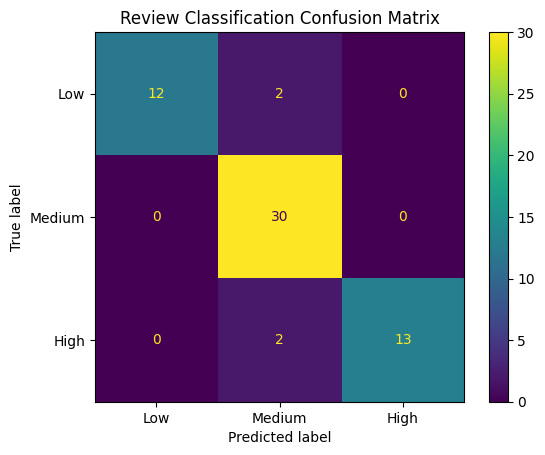

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Low", "Medium", "High"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Review Classification Confusion Matrix")
plt.show()

In [85]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Reviews,0.57264
0,Ratings,0.42736


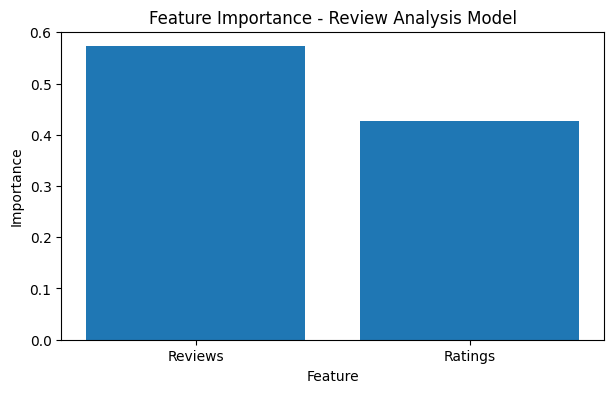

In [87]:
plt.figure(figsize=(7, 4))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance - Review Analysis Model")

plt.show()

In [88]:
probabilities = model.predict_proba(X_test)

probability_df = pd.DataFrame(
    probabilities,
    columns=model.classes_,
    index=X_test.index
)

probability_df.head()

,High,Low,Medium
14,0.02,0.01,0.97
147,0.97,0.00,0.03
2,1.00,0.00,0.00
104,0.96,0.00,0.04
186,1.00,0.00,0.00


In [90]:
predicted_probability = probabilities.max(axis=1)
prediction_output = pd.DataFrame({
    "Actual_Review_Class": y_test,
    "Predicted_Review_Class": y_pred,
    "Predicted_Probability": predicted_probability
}, index=X_test.index)

prediction_output.head()

,Actual_Review_Class,Predicted_Review_Class,Predicted_Probability
14,Medium,Medium,0.97
147,High,High,0.97
2,High,High,1.00
104,High,High,0.96
186,High,High,1.00


In [91]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


CV Scores: [0.96610169 0.93220339 0.94915254 0.94915254 0.87931034]
Mean CV Accuracy: 0.9351841028638223


In [93]:
model_mask = df["Review_Class"] != "No Review Data"

df.loc[model_mask, "Predicted_Review_Class"] = model.predict(
    df.loc[model_mask, ["Ratings", "Reviews"]]
)
all_probabilities = model.predict_proba(
    df.loc[model_mask, ["Ratings", "Reviews"]]
)

df.loc[model_mask, "Predicted_Review_Probability"] = (
    all_probabilities.max(axis=1)
)

In [94]:
df[
    [
        "Company",
        "Ratings",
        "Reviews",
        "Review_Class",
        "Predicted_Review_Class",
        "Predicted_Review_Probability"
    ]
].head(20)

,Company,Ratings,Reviews,Review_Class,Predicted_Review_Class,Predicted_Review_Probability
0,Ladies First Beauty Salon,4.5,399,High,High,1.00
1,Priya Beauty Salon,4.8,55,Medium,Medium,0.80
2,Looks,4.8,329,High,High,1.00
3,Glow N Glam\r,4.6,221,High,High,0.96
4,NY-2 Food Market,4.3,55,Medium,Medium,0.99
5,Noho Food Market,4.2,57,Medium,Medium,0.96
6,Parkview Convenience,5.0,3,Medium,Medium,0.98
7,NYC convenience (maiden lane),4.5,12,Medium,Medium,0.99
8,Sonny's Grocery store,4.5,15,Medium,Medium,1.00
9,Chelsea convenience & more,3.5,8,Low,Low,0.94


In [95]:
df["Predicted_Review_Class"].value_counts(dropna=False)

Predicted_Review_Class
Medium    152
High       72
Low        70
NaN         3
Name: count, dtype: int64

#MODEL EVALUTATION

In [97]:
mismatch = prediction_output[
    prediction_output["Actual_Review_Class"] !=
    prediction_output["Predicted_Review_Class"]
]

print("Incorrect predictions:", len(mismatch))
print("Total test records:", len(prediction_output))

Incorrect predictions: 4
Total test records: 59


In [98]:
print(mismatch)

    Actual_Review_Class Predicted_Review_Class  Predicted_Probability
79                 High                 Medium                   0.65
34                  Low                 Medium                   0.51
268                 Low                 Medium                   0.55
103                High                 Medium                   0.65


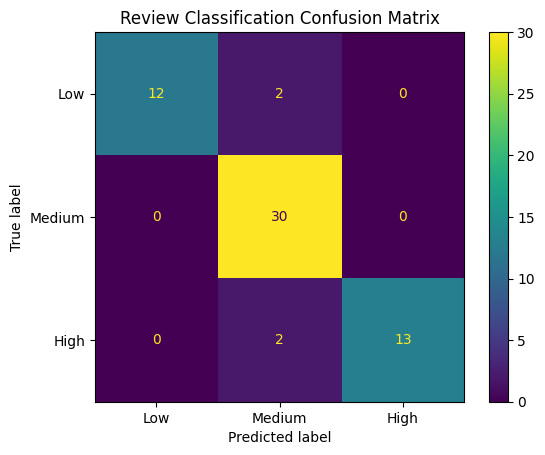

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["Low", "Medium", "High"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Review Classification Confusion Matrix")
plt.show()

In [100]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
1,Reviews,0.57264
0,Ratings,0.42736


In [101]:
# Predict Review Class for all businesses that have review data
model_mask = df["Review_Class"] != "No Review Data"

df.loc[model_mask, "Predicted_Review_Class"] = model.predict(
    df.loc[model_mask, ["Ratings", "Reviews"]]
)

# Get probability for each class
all_probabilities = model.predict_proba(
    df.loc[model_mask, ["Ratings", "Reviews"]]
)

# Get the probability of the predicted class
df.loc[model_mask, "Predicted_Review_Probability"] = (
    all_probabilities.max(axis=1)
)

# Keep the 3 no-review businesses separate
df.loc[~model_mask, "Predicted_Review_Class"] = "No Review Data"
df.loc[~model_mask, "Predicted_Review_Probability"] = np.nan

In [102]:
df[
    [
        "Company",
        "Country",
        "Business_Type",
        "Ratings",
        "Reviews",
        "Review_Class",
        "Predicted_Review_Class",
        "Predicted_Review_Probability"
    ]
].head(20)

,Company,Country,Business_Type,Ratings,Reviews,Review_Class,Predicted_Review_Class,Predicted_Review_Probability
0,Ladies First Beauty Salon,India,Indian,4.5,399,High,High,1.00
1,Priya Beauty Salon,India,Indian,4.8,55,Medium,Medium,0.80
2,Looks,India,Indian,4.8,329,High,High,1.00
3,Glow N Glam\r,India,Indian,4.6,221,High,High,0.96
4,NY-2 Food Market,USA,Foreign,4.3,55,Medium,Medium,0.99
5,Noho Food Market,USA,Foreign,4.2,57,Medium,Medium,0.96
6,Parkview Convenience,USA,Foreign,5.0,3,Medium,Medium,0.98
7,NYC convenience (maiden lane),USA,Foreign,4.5,12,Medium,Medium,0.99
8,Sonny's Grocery store,USA,Foreign,4.5,15,Medium,Medium,1.00
9,Chelsea convenience & more,USA,Foreign,3.5,8,Low,Low,0.94


In [103]:
df["Predicted_Review_Class"].value_counts(dropna=False)

Predicted_Review_Class
Medium            152
High               72
Low                70
No Review Data      3
Name: count, dtype: int64

In [104]:
comparison = pd.crosstab(
    df["Review_Class"],
    df["Predicted_Review_Class"],
    dropna=False
)

comparison

Predicted_Review_Class,High,Low,Medium,No Review Data
Review_Class,,,,
High,72,0,2,0
Low,0,70,2,0
Medium,0,0,148,0
No Review Data,0,0,0,3


In [105]:
df.to_csv(
    "BLC_C1_Final_Review_Analysis_Output.csv",
    index=False
)

In [106]:
# ==========================================
# CATEGORY PRIORITY 
# ==========================================

# 1. Calculate category-level performance
category_priority = (
    df.groupby("Clean_Category", as_index=False)
      .agg(
          Business_Count=("Company", "count"),
          Average_Rating=("Ratings", "mean"),
          Average_Reviews=("Reviews", "mean"),
          Average_Review_Score=("Review_Score", "mean")
      )
)

# 2. Sort categories by their average Review Score
category_priority = (
    category_priority
    .sort_values("Average_Review_Score", ascending=False)
    .reset_index(drop=True)
)

# 3. Give every category a priority rank
category_priority["Priority_Rank"] = range(
    1, len(category_priority) + 1
)

# 4. Create category-level High / Medium / Low tiers
Q1 = category_priority["Average_Review_Score"].quantile(0.25)
Q3 = category_priority["Average_Review_Score"].quantile(0.75)

category_priority["Priority_Tier"] = np.select(
    [
        category_priority["Average_Review_Score"] >= Q3,
        category_priority["Average_Review_Score"] <= Q1
    ],
    [
        "High",
        "Low"
    ],
    default="Medium"
)

# 5. Use the category's average Review Score as its
#    data-derived Category Lead Score
category_priority["Category_Lead_Score"] = (
    category_priority["Average_Review_Score"].round(3)
)

# 6. Round the other values for a clean table
category_priority["Average_Rating"] = (
    category_priority["Average_Rating"].round(2)
)

category_priority["Average_Reviews"] = (
    category_priority["Average_Reviews"].round(2)
)

category_priority["Average_Review_Score"] = (
    category_priority["Average_Review_Score"].round(3)
)

# 7. Display the final table
category_priority

,Clean_Category,Business_Count,Average_Rating,Average_Reviews,Average_Review_Score,Priority_Rank,Priority_Tier,Category_Lead_Score
0,Restaurant,23,4.32,2817.57,0.808,1,High,0.808
1,Beauty Salon,20,4.79,183.35,0.770,2,High,0.770
2,Building Materials Store,1,4.70,80.00,0.745,3,High,0.745
3,Home Goods Store,2,4.60,70.00,0.713,4,Medium,0.713
4,Cake Shop,41,4.27,468.61,0.692,5,Medium,0.692
5,Tailor,20,4.42,67.75,0.682,6,Medium,0.682
6,General Store,42,4.45,481.02,0.675,7,Medium,0.675
7,Wine Store,18,4.14,74.39,0.669,8,Medium,0.669
8,Grocery Store,16,4.36,91.38,0.668,9,Medium,0.668
9,Pharmacy,93,4.27,44.17,0.639,10,Low,0.639
